In [28]:

import numpy as np
import matplotlib.pyplot as plt

# Kalman Filter implementation
class DCMotorKalman:
    def __init__(self):
        self.N = 4
        self.M = 2

        self.A = np.array([
            [1.0, 9.02071e-5, -1.0601, 0.0633],
            [0.0, -0.00443, -1144.76, 68.04],
            [0.0, 0.0, 1.0, 0.0],
            [0.0, -6.1875e-5, 0.7307, 0.9459]
        ])
        self.B = np.array([[3.33e-4], [0.7213], [0.0], [0.0111]])
        self.C = np.array([
            [1, 0, 0, 0],
            [0, 0, 0, 1]
        ])
        self.Q = np.diag([0.0, 0.0, 1e-10, 0.0])
        self.R = np.diag([1.32e-6, 1.3e-6])

        self.x = np.zeros((self.N, 1))
        self.P = np.eye(self.N)
        self.errFlag = False

    def predict(self, u):
        self.x = np.dot(self.A, self.x) + self.B * u
        self.P = np.dot(self.A, np.dot(self.P, self.A.T)) + self.Q

    def update(self, y):
        y = np.reshape(y, (self.M, 1))
        y_residual = y - np.dot(self.C, self.x)
        S = np.dot(self.C, np.dot(self.P, self.C.T)) + self.R
        try:
            S_inv = np.linalg.inv(S)
            K = np.dot(self.P, np.dot(self.C.T, S_inv))
        except np.linalg.LinAlgError:
            self.errFlag = True
            return
        self.x = self.x + np.dot(K, y_residual)
        I = np.eye(self.N)
        self.P = np.dot(I - np.dot(K, self.C), self.P)

    def get_state(self):
        return self.x.flatten()

# Motor Plant simulation
class MotorPlant:
    def __init__(self):
        self.A = np.array([
            [1.0, 9.02071e-5, -1.0601, 0.0633], # [1.0, 9.02071e-5, -1.0601, 0.0633],
            [0.0, -0.00443, -1144.76, 68.04],
            [0.0, 0.0, 1.0, 0.0],
            [0.0, -6.1875e-5, 0.7307, 0.9459]
        ])
        self.B = np.array([[3.33e-4], [0.7213], [0.0], [0.0111]])
        self.C = np.array([
            [1, 0, 0, 0],
            [0, 0, 0, 1]
        ])
        self.R = np.diag([1.32e-2, 1.3e-3])
        self.x = np.zeros((4, 1))

    def step(self, u):
        self.x = np.dot(self.A, self.x) + self.B * u
        y = np.dot(self.C, self.x)
        return y.flatten(), self.x.flatten()

    def noisy_step(self, u):
        y_true, x_true = self.step(u)
        theta_noise = np.random.normal(0, np.sqrt(self.R[0, 0]))
        current_noise = np.random.normal(0, np.sqrt(self.R[1, 1]))
        y_noisy = y_true + np.array([theta_noise, current_noise])
        return y_noisy, x_true


In [29]:

np.random.seed(0)  # For reproducibility

T = 4.0
dt = 0.001
steps = int(T / dt)

kf = DCMotorKalman()
plant = MotorPlant()

theta_meas, current_meas = [], []
theta_est, omega_est, mL_est, current_est = [], [], [], []
time_axis = []

for i in range(steps):
    t = i * dt
    u = 3.0 if t < 2.0 else 8.0

    y_noisy, x_true = plant.noisy_step(u)

    kf.predict(u)
    kf.update(y_noisy)
    x_est = kf.get_state()

    theta_meas.append(y_noisy[0])
    current_meas.append(y_noisy[1])

    theta_est.append(x_est[0])
    omega_est.append(x_est[1])
    mL_est.append(x_est[2])
    current_est.append(x_est[3])
    time_axis.append(t)


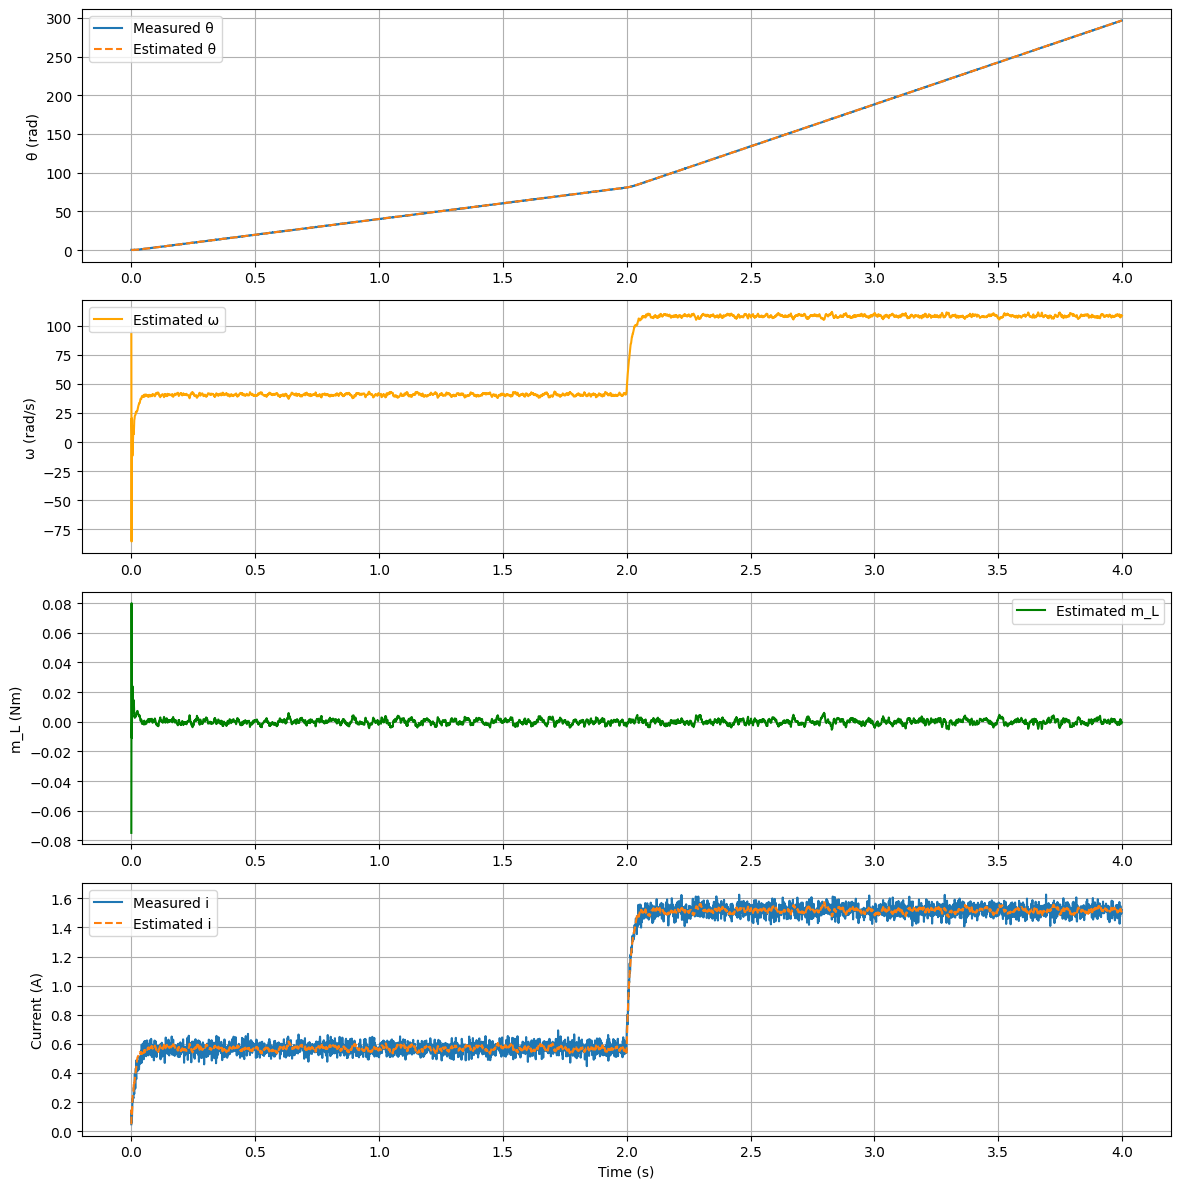

In [30]:

plt.figure(figsize=(12, 12))

plt.subplot(4, 1, 1)
plt.plot(time_axis, theta_meas, label='Measured θ')
plt.plot(time_axis, theta_est, label='Estimated θ', linestyle='--')
plt.ylabel('θ (rad)')
plt.legend()
plt.grid(True)

plt.subplot(4, 1, 2)
plt.plot(time_axis, omega_est, label='Estimated ω', color='orange')
plt.ylabel('ω (rad/s)')
plt.legend()
plt.grid(True)

plt.subplot(4, 1, 3)
plt.plot(time_axis, mL_est, label='Estimated m_L', color='green')
plt.ylabel('m_L (Nm)')
plt.legend()
plt.grid(True)

plt.subplot(4, 1, 4)
plt.plot(time_axis, current_meas, label='Measured i')
plt.plot(time_axis, current_est, label='Estimated i', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Current (A)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
